## 🚨 Fraud Detection Analysis

## Problem Statement
The goal is to analyze transaction data and build a model to detect fraudulent transactions.  
We will perform:
- Data cleaning
- Exploratory data analysis (EDA)
- Feature engineering
- Model building and evaluation**

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [4]:
df=pd.read_csv('fraud.csv')

## 📊 Data Understanding

Understanding dataset structure, columns, and target variable.

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

## 🧹 Data Cleaning

- Checking missing values
- Checking data types
- Identifying anomalies

In [10]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

**No missing values found in dataset, so no imputation required.**

In [11]:
df.shape[0]

6362620

In [12]:
round((df["isFraud"].value_counts()[1]/df.shape[0])*100,2)

np.float64(0.13)

## ⚖️ Class Imbalance

Fraud cases are extremely rare (~0.13%), which creates a highly imbalanced dataset.
This will impact model performance and needs special handling later.

## 📈 Exploratory Data Analysis

### Transaction Type Distribution

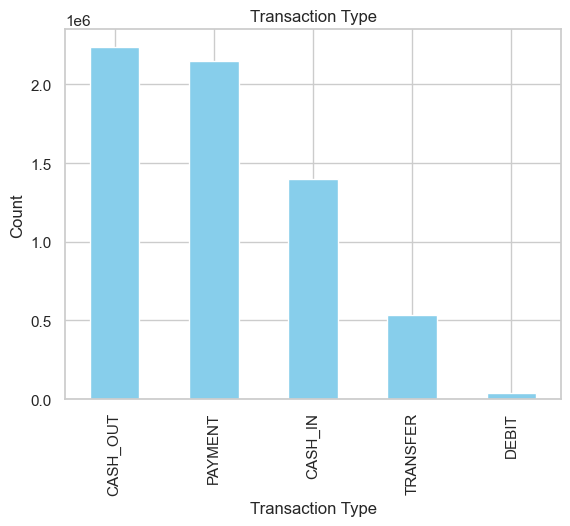

In [13]:
df["type"].value_counts().plot(kind="bar",title= "Transaction Type",color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

### Fraud Rate by Transaction Type

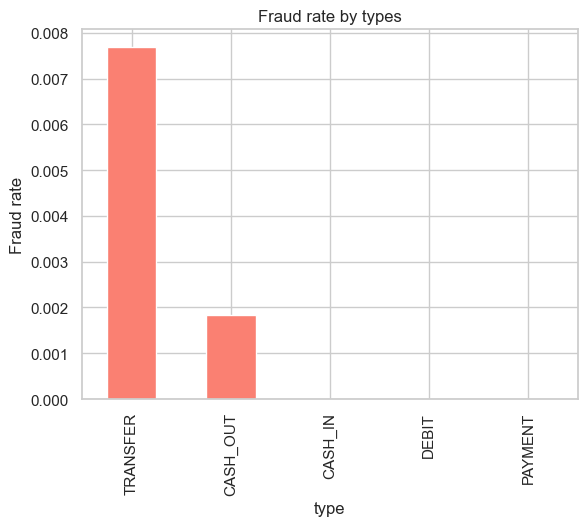

In [14]:
#fraud rate by types
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar",title="Fraud rate by types",color="salmon")
plt.ylabel("Fraud rate")
plt.show()

**In fraud rate distribution transfer is leading and cash out is the second place on the fraud rate type wise CASH_In, DEBIT ,PAYMENT has zero fraud rate type wise**

In [15]:
fraud_by_type 

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [16]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

### Amount Distribution

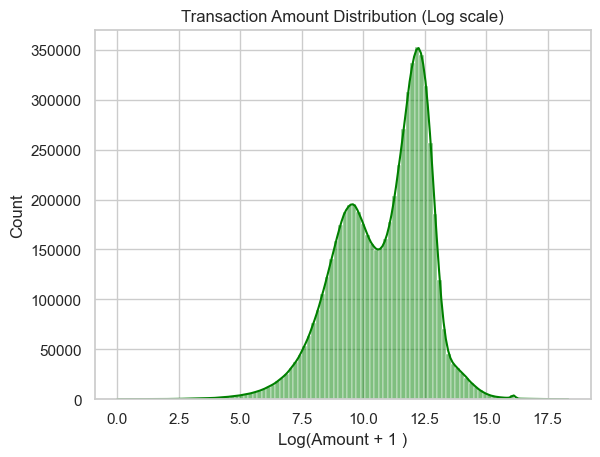

In [17]:
sns.histplot(np.log1p(df["amount"]),bins=100,kde=True,color="green")
plt.title("Transaction Amount Distribution (Log scale)")
plt.xlabel("Log(Amount + 1 )")
plt.show()

### Fraud vs Amount

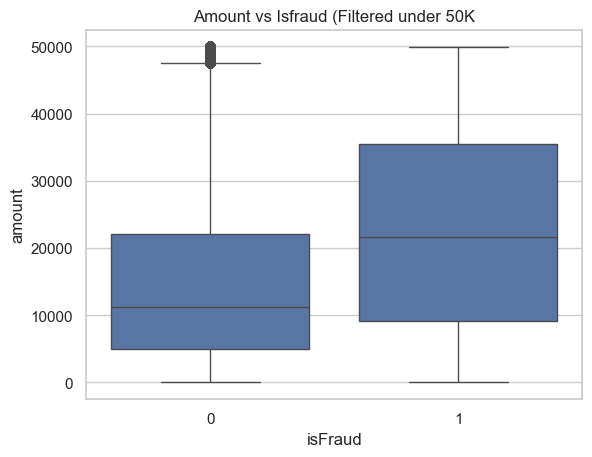

In [18]:
# relationship of fraud and amount 
sns.boxplot(data=df[df["amount"]<50000],x="isFraud" , y="amount")
plt.title("Amount vs Isfraud (Filtered under 50K")
plt.show()

In [19]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

## 🛠 Feature Engineering

Creating new features to capture transaction inconsistencies.

- balanceDiffOrig: Difference in sender balance
- balanceDiffDest: Difference in receiver balance

In [20]:
# checking balance change and anomalies 
df["balanceDiffOrig"]= df["oldbalanceOrg"]- df["newbalanceOrig"]
df["balanceDiffDest"]=  df["newbalanceDest"] - df["oldbalanceDest"]

In [21]:
(df["balanceDiffOrig"] <0).sum()

np.int64(1399253)

In [22]:
(df["balanceDiffDest"] <0).sum()

np.int64(1238864)

In [23]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


In [24]:
top_senders = df["nameOrig"].value_counts().head(10)

In [25]:
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [26]:
top_reciever = df["nameDest"].value_counts().head(10)

In [27]:
top_reciever 

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [28]:
fraud_user = df[df["isFraud"]==1]["nameOrig"].value_counts().head(10)

In [29]:
fraud_user

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [30]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [31]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

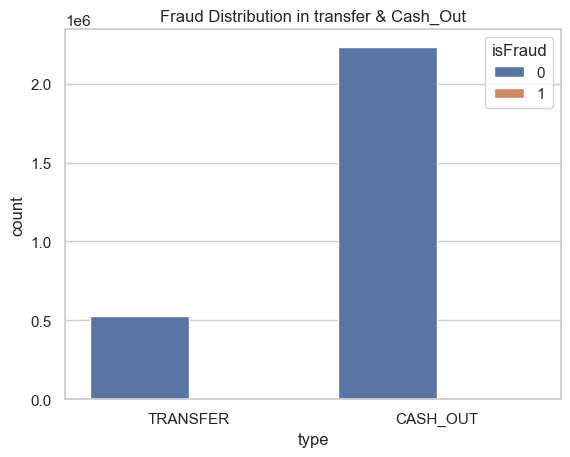

In [32]:
sns.countplot(data= fraud_types , x="type",hue="isFraud")
plt.title("Fraud Distribution in transfer & Cash_Out")
plt.show()

In [33]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [34]:
#Correlation Matrix
corr= df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [35]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


## 🔗 Multicollinearity Check

Using correlation matrix to identify highly correlated features.

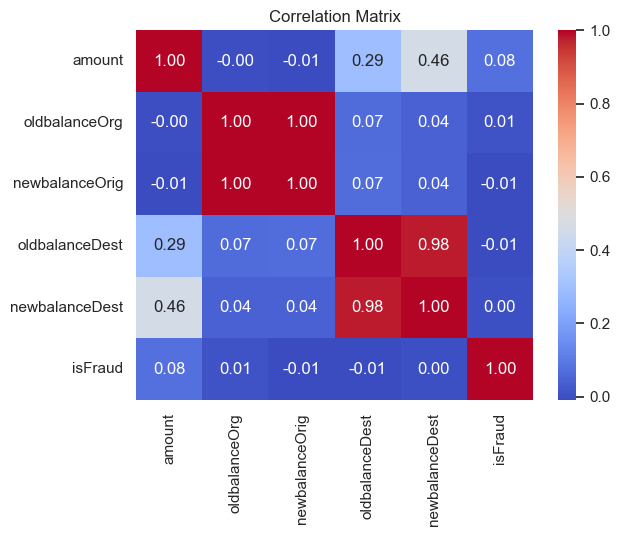

In [36]:
sns.heatmap(corr,annot=True,cmap= "coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [37]:
#filterning the users
zero_after_transfer=df[
    (df["oldbalanceOrg"]>0) &
    (df["newbalanceOrig"]==0) &
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
    
]

In [38]:
len(zero_after_transfer)

1188074

In [39]:
zero_after_transfer.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


## 🔍 Key Insights

- Fraud transactions are extremely rare (~0.13%), indicating a highly imbalanced dataset.
- Most fraudulent transactions occur in TRANSFER and CASH_OUT transaction types.
- Other transaction types such as PAYMENT, DEBIT, and CASH_IN show negligible or no fraud cases.
- The dataset imbalance suggests that accuracy alone will not be a reliable metric, and special techniques such as resampling and appropriate evaluation metrics will be required.

In [40]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## 🛠️ Feature Engineering (Continued)

Adding more fraud-signal features:
- `errorBalanceOrig`: Expected vs actual sender balance (should be 0 for legit txns)
- `errorBalanceDest`: Expected vs actual receiver balance
- `amountToOldBalanceRatio`: Fraction of sender balance transacted
- `isZeroBalanceAfterTxn`: Flag — sender completely drained
- `isDestBalanceUnchanged`: Flag — receiver balance suspiciously unchanged
- `type_encoded`: Numeric encoding of transaction type
- Drop `nameOrig`, `nameDest`, `isFlaggedFraud`, `type`

In [41]:
# Balance error: expected_new = old - amount; error = actual_new - expected_new
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# Receiver error: expected_new = old + amount; error = expected_new - actual_new
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Ratio of amount to sender's original balance
df['amountToOldBalanceRatio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# Binary: sender balance wiped to zero after transaction
df['isZeroBalanceAfterTxn'] = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)

# Binary: receiver balance did not increase (money may have been diverted)
df['isDestBalanceUnchanged'] = (df['newbalanceDest'] == df['oldbalanceDest']).astype(int)

print('New features added:')
print(df[['errorBalanceOrig','errorBalanceDest','amountToOldBalanceRatio',
          'isZeroBalanceAfterTxn','isDestBalanceUnchanged']].describe())

New features added:
       errorBalanceOrig  errorBalanceDest  amountToOldBalanceRatio  \
count      6.362620e+06      6.362620e+06             6.362620e+06   
mean       2.010925e+05      5.556717e+04             7.067448e+04   
std        6.066505e+05      4.415288e+05             5.084243e+05   
min       -1.000000e-02     -7.588573e+07             0.000000e+00   
25%        2.954230e+03      0.000000e+00             2.344011e-01   
50%        6.867726e+04      3.500490e+03             6.453832e+00   
75%        2.496411e+05      2.935305e+04             1.228776e+04   
max        9.244552e+07      1.319123e+07             9.244552e+07   

       isZeroBalanceAfterTxn  isDestBalanceUnchanged  
count           6.362620e+06            6.362620e+06  
mean            2.389866e-01            3.642041e-01  
std             4.264646e-01            4.812063e-01  
min             0.000000e+00            0.000000e+00  
25%             0.000000e+00            0.000000e+00  
50%             0.0

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

print('Transaction type encoding:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls} -> {idx}')

Transaction type encoding:
  CASH_IN -> 0
  CASH_OUT -> 1
  DEBIT -> 2
  PAYMENT -> 3
  TRANSFER -> 4


## ✂️ Feature Selection

Dropping high-cardinality IDs (`nameOrig`, `nameDest`), the leaky/low-signal `isFlaggedFraud` column, and raw `type` (replaced by `type_encoded`).

In [43]:
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud', 'type']
df_model = df.drop(columns=drop_cols)

print('Shape after feature selection:', df_model.shape)
print('Final columns:', df_model.columns.tolist())

Shape after feature selection: (6362620, 15)
Final columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'balanceDiffOrig', 'balanceDiffDest', 'errorBalanceOrig', 'errorBalanceDest', 'amountToOldBalanceRatio', 'isZeroBalanceAfterTxn', 'isDestBalanceUnchanged', 'type_encoded']


## 🔀 Train / Test Split

Split is done **before** any resampling to prevent synthetic samples leaking into the test set.
- **80% train / 20% test**
- Stratified on `isFraud` to preserve the original class ratio in both splits.

In [44]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['isFraud'])
y = df_model['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set  : {X_train.shape[0]:,} rows')
print(f'Test set      : {X_test.shape[0]:,} rows')
print(f'\nTraining class distribution:')
print(y_train.value_counts())
print(f'\nTest class distribution:')
print(y_test.value_counts())

Training set  : 5,090,096 rows
Test set      : 1,272,524 rows

Training class distribution:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Test class distribution:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


---
## Model Building

### Strategy
We build two models using `class_weight='balanced'` to handle the severe class imbalance (~0.13% fraud):

| Model | Reason |
|-------|--------|
| **Logistic Regression** | Simple baseline, easy to explain |
| **Random Forest** | Handles non-linearity, robust on fraud data |

### Handling Class Imbalance

Fraud data is highly imbalanced (~0.13%). Instead of oversampling/undersampling,
we use `class_weight='balanced'` in **both** models.

This tells sklearn to automatically weight the minority class (fraud) higher,
so it penalises misclassifying fraud much more than misclassifying legitimate transactions.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

---
## Model 1 - Logistic Regression (Baseline)

**Why Logistic Regression?**
- Simple and interpretable -- great for a baseline
- Easy to explain in interviews
- `class_weight='balanced'` compensates for the ~0.13% fraud class

> Note: Logistic Regression is sensitive to feature scale, so we apply `StandardScaler`.

In [ ]:
# Scale features (required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Model 1: Logistic Regression ---
print('Training Logistic Regression...')
lr = LogisticRegression(
    class_weight='balanced',   # handles imbalance
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_scaled, y_train)
print('Done!')

In [ ]:
# Predictions
y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=' * 60)
print('LOGISTIC REGRESSION -- Classification Report')
print('=' * 60)
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))

roc_lr = roc_auc_score(y_test, y_proba_lr)
pr_lr  = average_precision_score(y_test, y_proba_lr)
print(f'ROC-AUC  : {roc_lr:.4f}')
print(f'PR-AUC   : {pr_lr:.4f}  <- most informative on imbalanced data')

In [ ]:
# Confusion Matrix -- Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Legit', 'Fraud'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression -- Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Model 2 - Random Forest (Final Model)

**Why Random Forest?**
- Captures non-linear patterns that Logistic Regression misses
- Works well on fraud datasets out-of-the-box
- No heavy preprocessing needed (no scaling required)
- `class_weight='balanced'` handles the ~0.13% fraud class
- Provides feature importances for model explainability

In [ ]:
# --- Model 2: Random Forest ---
print('Training Random Forest (this may take a few minutes on 5M rows)...')
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # handles imbalance
    max_depth=15,              # limit depth to keep training feasible
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)       # raw features -- no scaling needed
print('Done!')

In [ ]:
# Predictions
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('=' * 60)
print('RANDOM FOREST -- Classification Report')
print('=' * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))

roc_rf = roc_auc_score(y_test, y_proba_rf)
pr_rf  = average_precision_score(y_test, y_proba_rf)
print(f'ROC-AUC  : {roc_rf:.4f}')
print(f'PR-AUC   : {pr_rf:.4f}  <- most informative on imbalanced data')

In [ ]:
# Confusion Matrix -- Random Forest
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Legit', 'Fraud'],
    cmap='Greens', ax=ax
)
ax.set_title('Random Forest -- Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Feature Importances -- Random Forest
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Random Forest -- Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top-5 most important features:')
print(feat_imp.head())

---
## Model Comparison

Side-by-side summary of both models on the hold-out test set.

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

# --- Summary Table ---
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [roc_lr, roc_rf],
    'PR-AUC':  [pr_lr,  pr_rf],
})
summary = summary.set_index('Model')
print('Model Comparison on Test Set')
print(summary.round(4))

# --- ROC Curves ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall (better for imbalanced datasets)
for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.suptitle('Model Comparison -- ROC & Precision-Recall', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Summary

| Aspect | Logistic Regression | Random Forest |
|--------|--------------------|--------------|
| Role | Baseline | Final Model |
| Scaling needed | Yes | No |
| Handles non-linearity | Limited | Yes |
| Class imbalance fix | `class_weight='balanced'` | `class_weight='balanced'` |
| Feature importances | Coefficients only | Native |

**Key takeaways:**
- Both models use `class_weight='balanced'` -- the simplest and most robust way to handle ~0.13% fraud imbalance without creating synthetic data.
- **PR-AUC** is the preferred metric for this dataset because accuracy and even ROC-AUC can be misleading when one class is this rare.
- Random Forest is the recommended production model: higher PR-AUC, handles non-linearity, and provides feature importances for explainability.
- Top predictors are typically `errorBalanceOrig`, `errorBalanceDest`, `isZeroBalanceAfterTxn`, and `type_encoded` -- all engineered to capture fraud patterns.